# EDA on NHANES 2021-2023 datasets

Here, we will load the NHANES 2021-2023 dataset, then perform some data preprocessing/cleaning and EDA.

## Loading data

Functions to extract data from data directory in current wd, then read as pandas dataframe.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob
import pathlib
from pathlib import Path
from functools import reduce

# Set data directory and base directory
base_dir = Path.cwd().parent
data_dir = base_dir / "data" / "raw" / "survey-data"

def load_xpts_as_dfs(data_dir):
    """
    Function to load XPT files in specified dir as a list of pandas dataframes

    Args:
        data_dir : directory containing .XPT files

    Returns:
        df_list : list of pandas dataframes
    """
    # Get filenames in the data directory
    file_names = os.listdir(data_dir)
    file_names = [data_dir / file for file in file_names]

    # Store as dfs 
    df_list = [pd.read_sas(file) for file in file_names]

    return df_list

def data_join(df_list):
    """
    Function to outer-join a list of dataframes using patient ID as join key

    Args:
        df_list : list of pandas dataframes
    
    Returns :
        joined_df : dataframe outer-joined by "SEQN" patient ID column
    """

    # Check that the "SEQN" patient ID column exists
    for i in range(len(df_list)):
        columns = df_list[i].columns

        if "SEQN" not in columns:
            raise KeyError(f"Patient ID column SEQN not present in dataframe {i}")
        
        else:
            # Convert patient ID to int and set as index
            df_list[i]["SEQN"] = df_list[i]["SEQN"].transform(lambda x: int(x))
            df_list[i] = df_list[i].set_index("SEQN")
    
    # Iterated outer_join, using patient ID on index as join key
    joined_df = reduce(lambda df1, df2 :
                       pd.concat([df1, df2], 
                                axis = 1,
                                join = "outer"),
                        df_list)
    
    return joined_df

Run functions on existing .XPT files.

In [2]:
# Load xpt data and check dimensions
df_list = load_xpts_as_dfs(data_dir)
data_df = data_join(df_list)

# Dimensions
print(f"# of individuals : {data_df.shape[0]}")
print(f"# of features    : {data_df.shape[1]}")

# of individuals : 11744
# of features    : 375


## Data cleaning

Our prediction target is asthma, so let's find the columns associated with the medical condition questionnaire ("MCQ_L.xpt"), then remove all but one column ("MCQ010").

In [3]:
# Choose medical condition file
label_file = data_dir / "MCQ_L.xpt"
label_df   = pd.read_sas(label_file)
label_df.set_index("SEQN", inplace = True)

# Select column names other than asthma column
rm_columns = [col for col in list(label_df.columns) if col != "MCQ010"]

# Remove those columns from the data
clean_data = data_df.drop(columns = rm_columns)

# Change label column to asthma
clean_data.rename(columns = {"MCQ010": "Asthma"}, inplace = True)

# Move labels to the last column
clean_data["Asthma"] = clean_data.pop("Asthma")

# Number of features after removing all medical condition labels
print(f"# features after removing labels : {clean_data.shape[1] - 1}")

# features after removing labels : 341


Examine duplicated column names.

In [4]:
# Select duplicated columns
duplicated = clean_data.columns.duplicated(keep = False)
duplicated_cols = clean_data.columns[duplicated]
duplicated_cols

Index(['WTPH2YR', 'WTPH2YR', 'WTPH2YR', 'WTPH2YR', 'WTPH2YR', 'WTPH2YR',
       'WTPH2YR', 'WTPH2YR', 'WTPH2YR', 'WTSAF2YR', 'WTPH2YR', 'WTPH2YR',
       'WTPH2YR', 'WTPH2YR', 'WTPH2YR', 'WTPH2YR', 'WTPH2YR', 'WTPH2YR',
       'WTSAF2YR', 'WTPH2YR', 'WTPH2YR', 'WTPH2YR', 'WTSAF2YR', 'WTPH2YR',
       'WTPH2YR'],
      dtype='str')

The duplicated columns all correspond to phlebotomy weights, which are not needed for this project. So, we can exclude all duplicate columns.

In [5]:
# Remove all duplicated columns
clean_data = clean_data.loc[:, ~duplicated]

# Number of features after removing all phlebotomy weights
print(f"# features after removing phlebotomy weights : {clean_data.shape[1] - 1}")

# features after removing phlebotomy weights : 316


We can convert the Asthma column to categorical labels and remove samples that have no label. According to the NHANES sample data, 1 means yes, 2 means 7, and 9 means, don't know. These codes might show up in other features, so let's define a map to convert these values.

In [6]:
# 1 is yes, 2 is no, 7 is declined response, 9 is no response
code_to_label = {1: 1, 2: 0, 7: np.nan, 9: np.nan}
clean_data["Asthma"] = clean_data["Asthma"].map(code_to_label)

Now remove all samples without an Asthma label.

In [7]:
# Grab all samples with no label
no_labels = clean_data["Asthma"].isna().to_numpy()

# Subsample
clean_data = clean_data.iloc[~no_labels]

# Number of samples after removing the unlabeled
print(f"# samples after removing unlabeled individuals : {clean_data.shape[0]}")

# samples after removing unlabeled individuals : 11728


Load the variable mapping csv and map the abbreviated column ID names to the actual features in the dataset.

In [9]:
# Store directory
map_dir = base_dir / "data" / "raw" / "variable-names"
map_file = map_dir / "variable-map.csv"

# Read csv file
pre_mappings = pd.read_table(map_file, sep = ",")
print(f"# of mapped variable names : {pre_mappings.shape[0]}")

# of mapped variable names : 388


In [10]:
pre_mappings.head(n = 5)

,Variable Name,Variable Description,Data File Name,Data File Description,Begin Year,EndYear,Component,Use Constraints
0,SEQN,Respondent sequence number.,UCPREG_L,Urine Pregnancy Test,2021,2023,Laboratory,NaN
1,URXPREG,Urine Pregnancy Result,UCPREG_L,Urine Pregnancy Test,2021,2023,Laboratory,NaN
2,LBXAGP,alpha-1-acid glycoprotein (g/L),AGP_L,alpha-1-Acid Glycoprotein,2021,2023,Laboratory,NaN
3,SEQN,Respondent sequence number.,AGP_L,alpha-1-Acid Glycoprotein,2021,2023,Laboratory,NaN
4,WTPH2YR,Phlebotomy 2 Year Weight,AGP_L,alpha-1-Acid Glycoprotein,2021,2023,Laboratory,NaN


Remove redundant variables and remove everything except for the variable name and variable description.

In [11]:
# Remove all the redundant rows
mappings = pre_mappings.iloc[~pre_mappings["Variable Name"].duplicated()]

# Keep first 2 columns
keep_cols = ["Variable Name", "Variable Description"]
mappings = mappings[keep_cols]
mappings = mappings.reset_index(drop = True)

print(f"How many ")
mappings.head(n = 5)

How many 


,Variable Name,Variable Description
0,SEQN,Respondent sequence number.
1,URXPREG,Urine Pregnancy Result
2,LBXAGP,alpha-1-acid glycoprotein (g/L)
3,WTPH2YR,Phlebotomy 2 Year Weight
4,LBDFERSI,Ferritin(µg/L)


The study has several variables where the many of the responses were NAs. We'd like to plot the number of excluded features as a function of the &NA threshold that we impose on the dataset. This will allow us to see what a reasonable %NA cutoff is to prune features before using the data for training.

In [29]:
def excluded_features(data_df, na_cutoff):
    """
    Function to calculate the % of excluded features (and also which ones) in a dataset as a function of the %NA cutoff
    
    Args:
        data_df   : dataframe with features on columns
        na_cutoff : %NA cutoff (0-1)

    Returns:
        percent_excluded : % of columns above the %NA threshold
        which_excluded   : list of names of excluded columns
    """
    # Compute percent NA for each column
    n_samples, n_features = data_df.shape
    percent_nas = [data_df.iloc[:,i].isna().sum() / n_samples for i in range(n_features)]
    percent_nas = np.array(percent_nas)

    # Impose NA cutoff
    excluded = percent_nas > na_cutoff
    percent_excluded = np.sum(excluded) / len(excluded)
    which_excluded = data_df.columns[excluded]

    return percent_excluded, which_excluded

Plot

Text(0, 0.5, '% of features remaining in dataset')

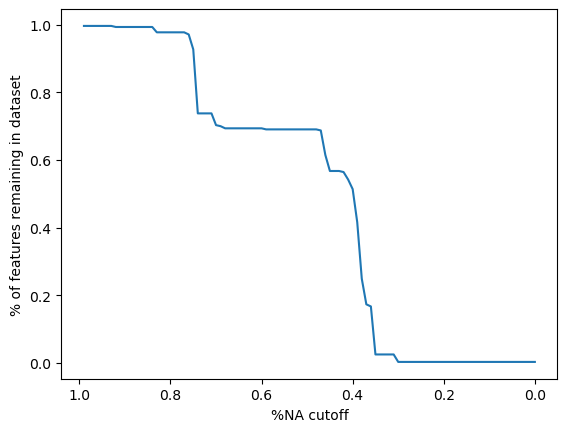

In [38]:
# Compute the percent excluded for several NA cutoffs from 0-1
cutoffs = np.arange(0, 1, step = 0.01)
percent_remaining = [1 - excluded_features(clean_data, cutoff)[0] for cutoff in cutoffs]

# Plot
fig, ax = plt.subplots()
ax.plot(cutoffs, percent_remaining)
ax.invert_xaxis()
ax.set_xlabel("%NA cutoff")
ax.set_ylabel("% of features remaining in dataset")

Rapid jump from 0.8 to 0.6 cutoff indicates that there may be a large number of features which all have the same group of samples missing. This makes sense given the fact that the dataset was not collected from a single population at once, but rather through repeated sessions.

Try a visualization of which samples the NA values tend to be in? Could make some sort of binary heatmap for NA values using the entire matrix, then group columns by similarity to see if a specific subset of the population is consistently missing values. 

Some things to do:
- Filter out features with more than 50% NaN (or decide some other reasonable threshold)
Check for outlier values
- Deal with NaNs using imputation techniques 
- Filter out features that have more than 50% NaNs

Possible model architectures:
- Logistic regression baseline
- Randomforest
- XGboost
- LigthGBM 